<a href="https://colab.research.google.com/github/AdnanAnwarR/practice_DS/blob/main/Assignment_Day_10_Adnan_Hypothesis_Testing_Concepts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

import library

In [30]:
import pandas as pd #Python for Data Analysis
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind #SCIENTIFIC PYTHON(scipy)
from scipy.stats import chisquare #scientific python for testing using chi square
from scipy.stats import f_oneway #scientific python for testing using anova one way

Load Data

In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
df = pd.read_csv("/content/drive/My Drive/dibimbing/Tugas/Assignment Day 10 Adnan/marketing_campaign.csv",sep= "\t")

1. Eksplorasi dan Statistik Deskriptif
* Pahami struktur dataset yang digunakan dan identifikasi variabel penting.
* Gunakan teknik eksplorasi data untuk mengenali pola dan karakteristik data.
* Tampilkan ringkasan statistik deskriptif yang memberikan gambaran tentang distribusi data.
* Interpretasikan hasil eksplorasi untuk memahami distribusi data dan kemungkinan permasalahan dalam dataset.


---
* cek berapa banyak data

In [40]:
df.head(10)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
5,7446,1967,Master,Together,62513.0,0,1,09-09-2013,16,520,...,6,0,0,0,0,0,0,3,11,0
6,965,1971,Graduation,Divorced,55635.0,0,1,13-11-2012,34,235,...,6,0,0,0,0,0,0,3,11,0
7,6177,1985,PhD,Married,33454.0,1,0,08-05-2013,32,76,...,8,0,0,0,0,0,0,3,11,0
8,4855,1974,PhD,Together,30351.0,1,0,06-06-2013,19,14,...,9,0,0,0,0,0,0,3,11,1
9,5899,1950,PhD,Together,5648.0,1,1,13-03-2014,68,28,...,20,1,0,0,0,0,0,3,11,0


In [34]:
df.tail()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0
2239,9405,1954,PhD,Married,52869.0,1,1,15-10-2012,40,84,...,7,0,0,0,0,0,0,3,11,1


* ada 2239 baris data


---
* cek tipe data masing masing kolom

In [35]:
df.dtypes

,0
ID,int64
Year_Birth,int64
Education,object
Marital_Status,object
Income,float64
Kidhome,int64
Teenhome,int64
Dt_Customer,object
Recency,int64
MntWines,int64



---------
* cek mising value


In [36]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


* di kolom incone ada data yang kosong sebanyak 24



---
* cek data duplikat

In [37]:
df.duplicated().sum()

np.int64(0)

* tidak ada data yang duplikat

---
* menampilkan ringkasan statistik

In [38]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


* disini saya akan pakai income  dan response

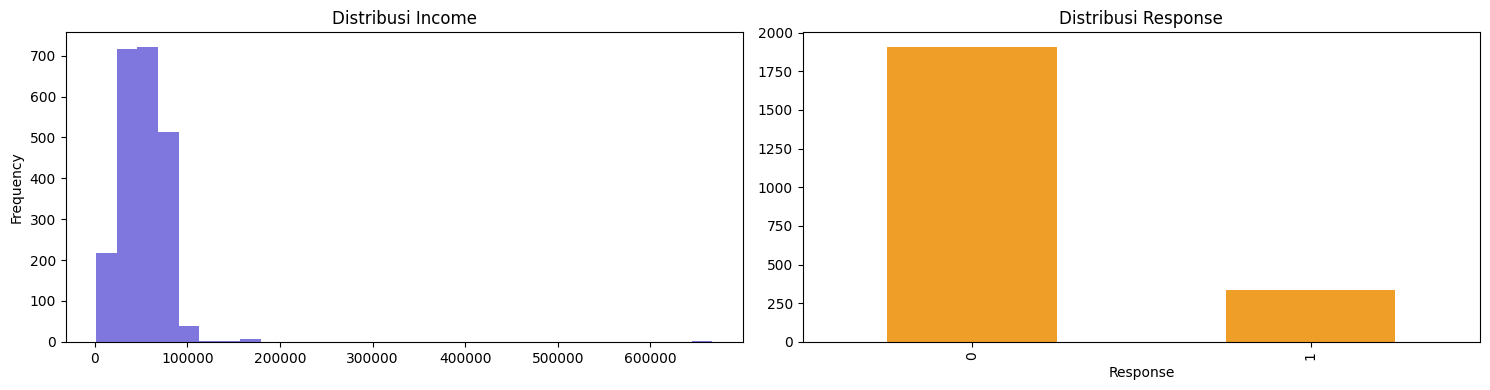

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

df["Income"].dropna().plot(kind="hist", bins=30, ax=axes[0], color="#7F77DD")
axes[0].set_title("Distribusi Income")

df["Response"].value_counts().plot(kind="bar", ax=axes[1], color="#EF9F27")
axes[1].set_title("Distribusi Response")

plt.tight_layout()
plt.show()

1. Jadi pada dataset terdapat missing value di kolom incone sebanyak 24
2. disini saya memilih kolom income dan respon
3. dari gambar distribusinya
* Mayoritas pelanggan berpenghasilan di kisaran 0 - 100.000
* Banyak yang tidak merespon lebih banyak dari yang merespon

2. Uji Hipotesis
* Definisikan hipotesis yang relevan sesuai dengan tujuan analisis.
* Pilih metode uji hipotesis yang sesuai dengan jenis data dan tujuan analisis.
* Pastikan pemilihan metode (misalnya t-test, ANOVA, atau Chi-Square) dilakukan dengan mempertimbangkan asumsi statistik yang diperlukan.
* Hitung nilai p-value dan interpretasikan hasilnya untuk menentukan apakah H0 dapat diterima atau ditolak.

Goal: Menguji hipotesis menggunakan metode statistik yang sesuai dan menginterpretasikan hasilnya.


* Disini untuk hipotesis saya

H0 : Tidak ada perbedaan Income antara pelanggan yang merespon dan tidak

H1 : Ada perbedaan Income antara pelanggan yang merespon dan tidak

* disini saya pilih metode T-Test Karena membandingkan 1 kolom numerik (Income) antara 2 grup (Response 0 vs 1)

In [47]:
group_0 = df[df["Response"] == 0]["Income"].dropna()
group_1 = df[df["Response"] == 1]["Income"].dropna()

# Hitung T-Test
t_stat, p_value = ttest_ind(group_0, group_1)

print(f"T-Statistic : {t_stat:.4f}")
print(f"P-Value     : {p_value:.4f}")

T-Statistic : -6.3164
P-Value     : 0.0000


In [48]:
# Interpretasi hasil
print("Interpretasi:")
if p_value < 0.05:
    print(f"P-Value {p_value:.4f} < 0.05 → H0 DITOLAK")
    print("Ada perbedaan Income yang signifikan antara pelanggan yang merespon dan tidak")
else:
    print(f"P-Value {p_value:.4f} > 0.05 → H0 DITERIMA")
    print("Tidak ada perbedaan Income yang signifikan antara pelanggan yang merespon dan tidak")

Interpretasi:
P-Value 0.0000 < 0.05 → H0 DITOLAK
Ada perbedaan Income yang signifikan antara pelanggan yang merespon dan tidak


3. Interpretasi dan Kesimpulan
* Analisis hasil uji hipotesis dan hubungkan dengan konteks data.
* Tinjau dampak dari hasil analisis terhadap pengambilan keputusan atau langkah selanjutnya dalam penelitian.
* pastikan kesimpulan didukung oleh hasil statistik yang diperoleh.


Goal: Menarik kesimpulan berdasarkan hasil analisis statistik.

* Kesimpulan : Jadi pelanggan yang merespon kampanye rata-rata memiliki Income lebih tinggi dibanding yang tidak merespon

# Reflection Question
Setelah menyelesaikan studi kasus ini, jelaskan dengan bahasa Anda sendiri.


1. Setelah melakukan uji hipotesis, apa hal yang membuatmu menyadari bahwa keputusan menerima atau menolak H0 tidak hanya bergantung pada angka p-value, tetapi juga pada konteks data dan tujuan analisis? Jelaskan bagaimana pemahaman ini memengaruhi cara kamu menafsirkan hasil uji statistik.
2. Selama proses mendefinisikan hipotesis dan memilih metode pengujian, bagian mana yang paling membantumu memahami mengapa asumsi statistik (seperti normalitas atau independensi) penting sebelum melakukan uji hipotesis? Ceritakan bagaimana pemahaman ini mengubah cara kamu memilih metode yang tepat.


# Jawaban

1. Hal yang menyadarkan saya adalah ketika melihat bahwa angka p-value 0.0000 secara teknis memang menolak H
0, namun konteks data melalui visualisasi distribusi menunjukkan bahwa perbedaan tersebut memiliki makna bisnis yang nyata, yaitu pelanggan yang merespons kampanye cenderung memiliki pendapatan lebih tinggi.
* Tidak terpaku pada angka: Saya tidak hanya melihat apakah p-value < 0.05, tetapi juga melihat arah dan besarnya perbedaan antar grup melalui visualisasi data.  

* Menghubungkan dengan tujuan: Hasil statistik digunakan untuk mendukung pengambilan keputusan praktis, seperti menargetkan segmen pelanggan berpendapatan tinggi di kampanye berikutnya, bukan sekadar urusan matematis.

2. Bagian yang paling membantu memahami pentingnya asumsi statistik adalah saat melakukan Eksplorasi Data (EDA) melalui visualisasi histogram dan ringkasan statistik describe().  

* Membuat Asumsi: Dengan melihat grafik "Distribusi Income", saya menyadari bahwa sebelum melakukan T-Test, saya harus memastikan data berdistribusi normal dan tidak terganggu oleh outlier ekstrem agar hasil uji tidak bias.  

* Memilih Metode: Pemahaman ini mengubah cara saya bekerja menjadi lebih teliti; saya tidak langsung menghitung statistik, tetapi melakukan pembersihan data (seperti dropna() untuk mengatasi missing value) dan memastikan tipe data sesuai (numerik vs kategori) agar metode yang dipilih, seperti T-Test atau ANOVA, benar-benar valid untuk menjawab hipotesis.